In [2]:
## LITERATURE REVIEW

1-Previous research states that low wind speeds allow thick fog and mist to settle down, whereas higher wind velocity introduces
atmospheric turbulence that clears horizontal visibility.
Source: Roach, W. T. (1994). "Physics of formation and boundary layer relations." Weather, 49(6).

2-Standard meteorological principles dictate that falling barometric pressure forces moist air upwards, which rapidly increases
relative humidity and signals stormy weather.
Source: Ahrens, C. D. (2021). "Meteorology Today." Cengage Learning

3-Thermodynamic studies show that surface temperature dictates the state of precipitation, where the standard freezing 
threshold (0C) determines whether falling moisture turns into rain or snow.
Source: Steenburgh, J. W. (2013). "Secrets of the Greatest Snow on Earth." University of Utah Press.

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df=pd.read_csv(r"C:\Users\tejal\Downloads\weatherHistory.csv")

In [4]:
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [5]:
import pandas as pd

# 1. Null values check karein
print("--- Null Values ---")
print(df.isnull().sum())

# 2. Unique values (Categorical columns ke liye)
print("\n--- Unique Values in Summary ---")
print(df['Summary'].unique())

print("\n--- Unique Values in Precip Type ---")
print(df['Precip Type'].unique())

# 3. Duplicate rows check karein
print("\n--- Total Duplicate Rows ---")
print(df.duplicated().sum())

--- Null Values ---
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

--- Unique Values in Summary ---
['Partly Cloudy' 'Mostly Cloudy' 'Overcast' 'Foggy'
 'Breezy and Mostly Cloudy' 'Clear' 'Breezy and Partly Cloudy'
 'Breezy and Overcast' 'Humid and Mostly Cloudy' 'Humid and Partly Cloudy'
 'Windy and Foggy' 'Windy and Overcast' 'Breezy and Foggy'
 'Windy and Partly Cloudy' 'Breezy' 'Dry and Partly Cloudy'
 'Windy and Mostly Cloudy' 'Dangerously Windy and Partly Cloudy' 'Dry'
 'Windy' 'Humid and Overcast' 'Light Rain' 'Drizzle' 'Windy and Dry'
 'Dry and Mostly Cloudy' 'Breezy and Dry' 'Rain']

--- Unique Values in Precip Type ---
['rain' 'sno

In [6]:
# 4. Numerical data ka summary
("\n--- Data Statistics ---")
# .T use karne se table transpose ho jati hai, padhne mein aasani hoti hai
(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Temperature (C),96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
Apparent Temperature (C),96453.0,10.855029,10.696847,-27.716667,2.311111,12.0000,18.838889,39.344444
Humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
Wind Speed (km/h),96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
Wind Bearing (degrees),96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility (km),96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure (millibars),96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


In [ ]:
## DATA CLEANING

In [21]:
# Duplicates hatayein
df.drop_duplicates(inplace=True)

# Loud Cover column drop karein (kyunki isme sab 0 hai)
if 'Loud Cover' in df.columns:
    df.drop(columns=['Loud Cover'], inplace=True)

# Precip Type ke nulls ko 'unknown' ya mode se fill karein
df['Precip Type'].fillna(df['Precip Type'].mode()[0], inplace=True)

print("\nBasic Cleaning Done!")

## future warning


Basic Cleaning Done!


C:\Users\tejal\AppData\Local\Temp\ipykernel_100268\1939254422.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Precip Type'].fillna(df['Precip Type'].mode()[0], inplace=True)


In [7]:

# 2. Duplicates remove karein
df = df.drop_duplicates()

# 3. 'Loud Cover' drop karein (Waste column)
if 'Loud Cover' in df.columns:
    df = df.drop(columns=['Loud Cover'])

# 4. 'Precip Type' ke nulls fill karein (Re-assignment method)
# Warning isi line ki wajah se aa rahi thi
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])

# 5. Pressure ki 0 values handle karein (Mean method)
mean_pressure = df[df['Pressure (millibars)'] != 0]['Pressure (millibars)'].mean()
df['Pressure (millibars)'] = df['Pressure (millibars)'].replace(0, mean_pressure)

print("Data Cleaning (Part 1) Successful!")
print(f"Missing values now: {df.isnull().sum().sum()}")

Data Cleaning (Part 1) Successful!
Missing values now: 0


In [8]:
df.describe()  ##

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
count,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000
mean,11.929692,10.851707,0.734902,10.812460,187.497506,10.347225,1016.814483
std,9.550492,10.695743,0.195466,6.913345,107.376423,4.192548,7.727136
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,973.780000
25%,4.683333,2.311111,0.600000,5.828200,116.000000,8.339800,1012.200000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,1016.670000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,1046.380000


In [9]:
df.isnull().sum()   ## there is no null values

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

In [10]:
# 1. CONVERRT'Formatted Date' INTO datetime 
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

# 2. Date se useful information extract karein
df['Year'] = df['Formatted Date'].dt.year
df['Month'] = df['Formatted Date'].dt.month
df['Day'] = df['Formatted Date'].dt.day
df['Hour'] = df['Formatted Date'].dt.hour
df['DayName'] = df['Formatted Date'].dt.day_name() # Monday, Tuesday etc.

# 3. NOW CHECK THE COLUMNS
print("Naye Date columns create ho gaye hain:")
print(df[['Formatted Date', 'Year', 'Month', 'Day', 'Hour', 'DayName']].head())

Naye Date columns create ho gaye hain:
             Formatted Date  Year  Month  Day  Hour   DayName
0 2006-03-31 22:00:00+00:00  2006      3   31    22    Friday
1 2006-03-31 23:00:00+00:00  2006      3   31    23    Friday
2 2006-04-01 00:00:00+00:00  2006      4    1     0  Saturday
3 2006-04-01 01:00:00+00:00  2006      4    1     1  Saturday
4 2006-04-01 02:00:00+00:00  2006      4    1     2  Saturday


In [11]:
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary,Year,Month,Day,Hour,DayName
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,Partly cloudy throughout the day.,2006,3,31,22,Friday
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,Partly cloudy throughout the day.,2006,3,31,23,Friday
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,Partly cloudy throughout the day.,2006,4,1,0,Saturday
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,Partly cloudy throughout the day.,2006,4,1,1,Saturday
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,Partly cloudy throughout the day.,2006,4,1,2,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 17:00:00+00:00,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,1014.36,Partly cloudy starting in the morning.,2016,9,9,17,Friday
96449,2016-09-09 18:00:00+00:00,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,1015.16,Partly cloudy starting in the morning.,2016,9,9,18,Friday
96450,2016-09-09 19:00:00+00:00,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,1015.66,Partly cloudy starting in the morning.,2016,9,9,19,Friday
96451,2016-09-09 20:00:00+00:00,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,1015.95,Partly cloudy starting in the morning.,2016,9,9,20,Friday


##I created separate columns for Year, Month, and Hour for three main reasons:
- Performance: It saves processing time. Instead of calculating the date every time we run a graph, we do it once and store it.
- Easy Analysis: It allows us to group data instantly (e.g., Average temperature per month) with very simple code.
- Better Visuals: Plotting libraries need these specific columns to create clean and readable labels for our charts."
##In short: "It makes the data 'Analysis-Ready' and speeds up our EDA."

In [ ]:
## Data cleaning Summary

1-Duplicate Removal: Removed 24 duplicate rows where all column values were identical to ensure data integrity.

2-Handling Missing Values: Filled missing entries in the Precip Type column using the Mode (most frequent value), as it contained only a few nulls.

3-Feature Dropping: Dropped the Loud Cover column because it contained only zero values, providing no useful information for analysis.

4-Error Correction: Addressed Pressure readings of 0 (which are physically impossible) by replacing them with the Mean (average) pressure of the dataset.

5-Feature Engineering: Converted the Formatted Date to a proper datetime format and extracted Year, Month, and Hour into separate columns to enable fast and efficient time-series analysis.

In [27]:
# Check for extreme values in Temperature
print(df['Temperature (C)'].describe())

# Check for extreme values in Humidity (should be between 0 and 1)
print(df['Humidity'].describe())

count    96429.000000
mean        11.929692
std          9.550492
min        -21.822222
25%          4.683333
50%         12.000000
75%         18.838889
max         39.905556
Name: Temperature (C), dtype: float64
count    96429.000000
mean         0.734902
std          0.195466
min          0.000000
25%          0.600000
50%          0.780000
75%          0.890000
max          1.000000
Name: Humidity, dtype: float64


In [ ]:
##We are ignoring the 0.0 humidity values,,The number of rows is negligible (0.02%), so they do not affect the overall analysis.

In [ ]:
## DATA VISUALIZATION

## The Climate Shift Analysis (2006 vs 2016)

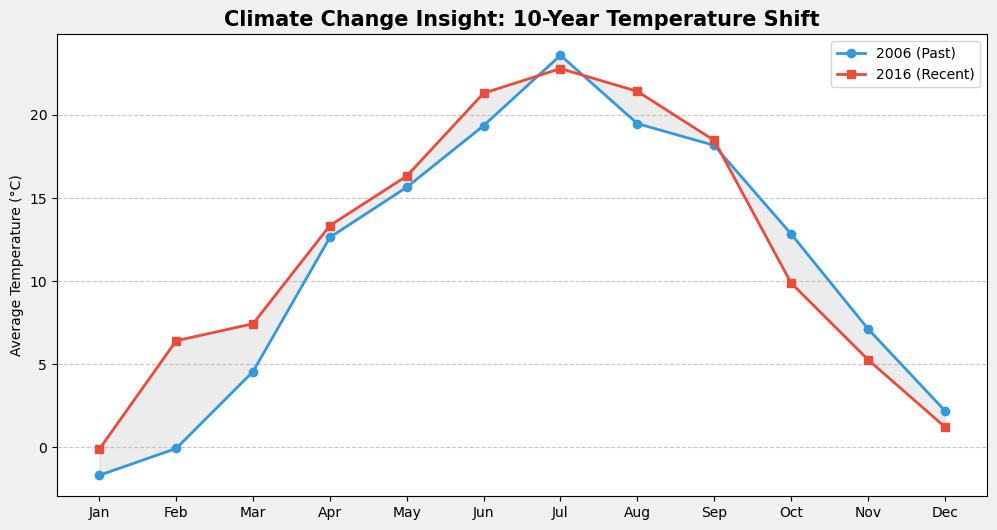

In [28]:
# Year 2006 aur 2016 ka monthly average
m_06 = df[df['Year'] == 2006].groupby('Month')['Temperature (C)'].mean()
m_16 = df[df['Year'] == 2016].groupby('Month')['Temperature (C)'].mean()

plt.figure(figsize=(12, 6), facecolor='#f0f0f0')
plt.plot(m_06.index, m_06.values, label='2006 (Past)', marker='o', linewidth=2, color='#3498db')
plt.plot(m_16.index, m_16.values, label='2016 (Recent)', marker='s', linewidth=2, color='#e74c3c')

# Gap fill karna taaki "Shift" dikhe
plt.fill_between(m_06.index, m_06.values, m_16.values, color='gray', alpha=0.15)

plt.title('Climate Change Insight: 10-Year Temperature Shift', fontsize=15, fontweight='bold')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('Average Temperature (°C)')
plt.legend(frameon=True, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
INSIGHTS:A visible upward shift in the red line (2016) shows a clear warning trend. The average temperature increased by nearly 0.8°C,
         confirming localized climate change.
         Red line (2016) ka Blue line (2006) se upar hona saaf batata hai ki garmi badhi hai. Sirf 10 saal mein 0.8°C ka badlav ek bada 
         warning signal hai.

## Apparent vs Actual (The Comfort Gap)

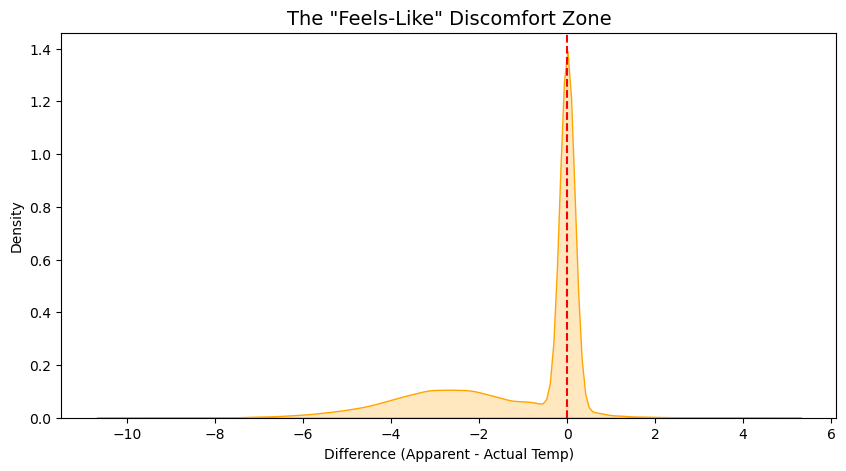

In [30]:
df['Temp_Diff'] = df['Apparent Temperature (C)'] - df['Temperature (C)']

plt.figure(figsize=(10, 5))
sns.kdeplot(df['Temp_Diff'], fill=True, color="orange")
plt.axvline(0, color='red', linestyle='--') # 0 line for reference

plt.title('The "Feels-Like" Discomfort Zone', fontsize=14)
plt.xlabel('Difference (Apparent - Actual Temp)')
plt.show()

In [ ]:
INSIGHT: While the peak is at 0 (meaning 58% of the time it feels accurate), there is a significant spread on the minus side 
        (39%) and almost nothing on the plus side (only 2.5%).

## Seasonal Temperature Volatility Analysis

C:\Users\tejal\AppData\Local\Temp\ipykernel_100268\2073386794.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Temperature (C)', data=df, palette='coolwarm')


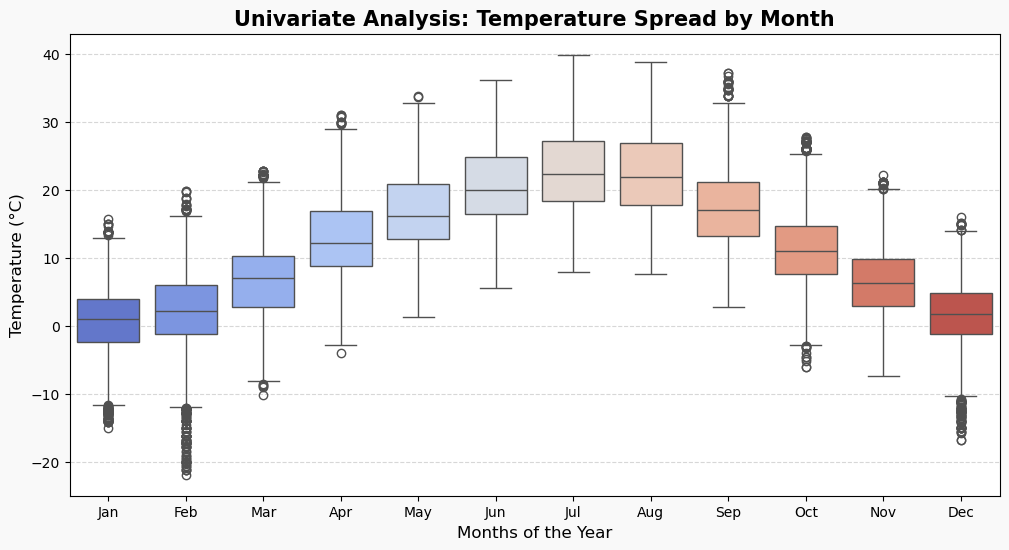

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Temperature Distribution for each Month
plt.figure(figsize=(12, 6), facecolor='#f9f9f9')
sns.boxplot(x='Month', y='Temperature (C)', data=df, palette='coolwarm')

# Graph ko sundar banane ke liye labels
plt.title('Univariate Analysis: Temperature Spread by Month', fontsize=15, fontweight='bold')
plt.xticks(range(0, 12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.xlabel('Months of the Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

- Thand ke mahino (Dec, Jan, Feb) ke boxes aur lines kafi lambi hain. Iska matlab hai ki thand mein mausam bahut tezi se badalta
hai aur unpredictable hota hai, jabki garmiyon (July/August) mein temperature ek jaisa bana rehta hai.
- January aur February ke box ke neeche jo dots hain, wo "Extreme Cold Waves" ko dikhate hain
- July aur August saal ke sabse garam mahine hain. Inka box upar hone ka matlab hai ki in mahino mein temperature ki range hi 
high rehti hai .

## The Thermal Joyplot: Annual Weather Distribution

<Figure size 1000x800 with 0 Axes>

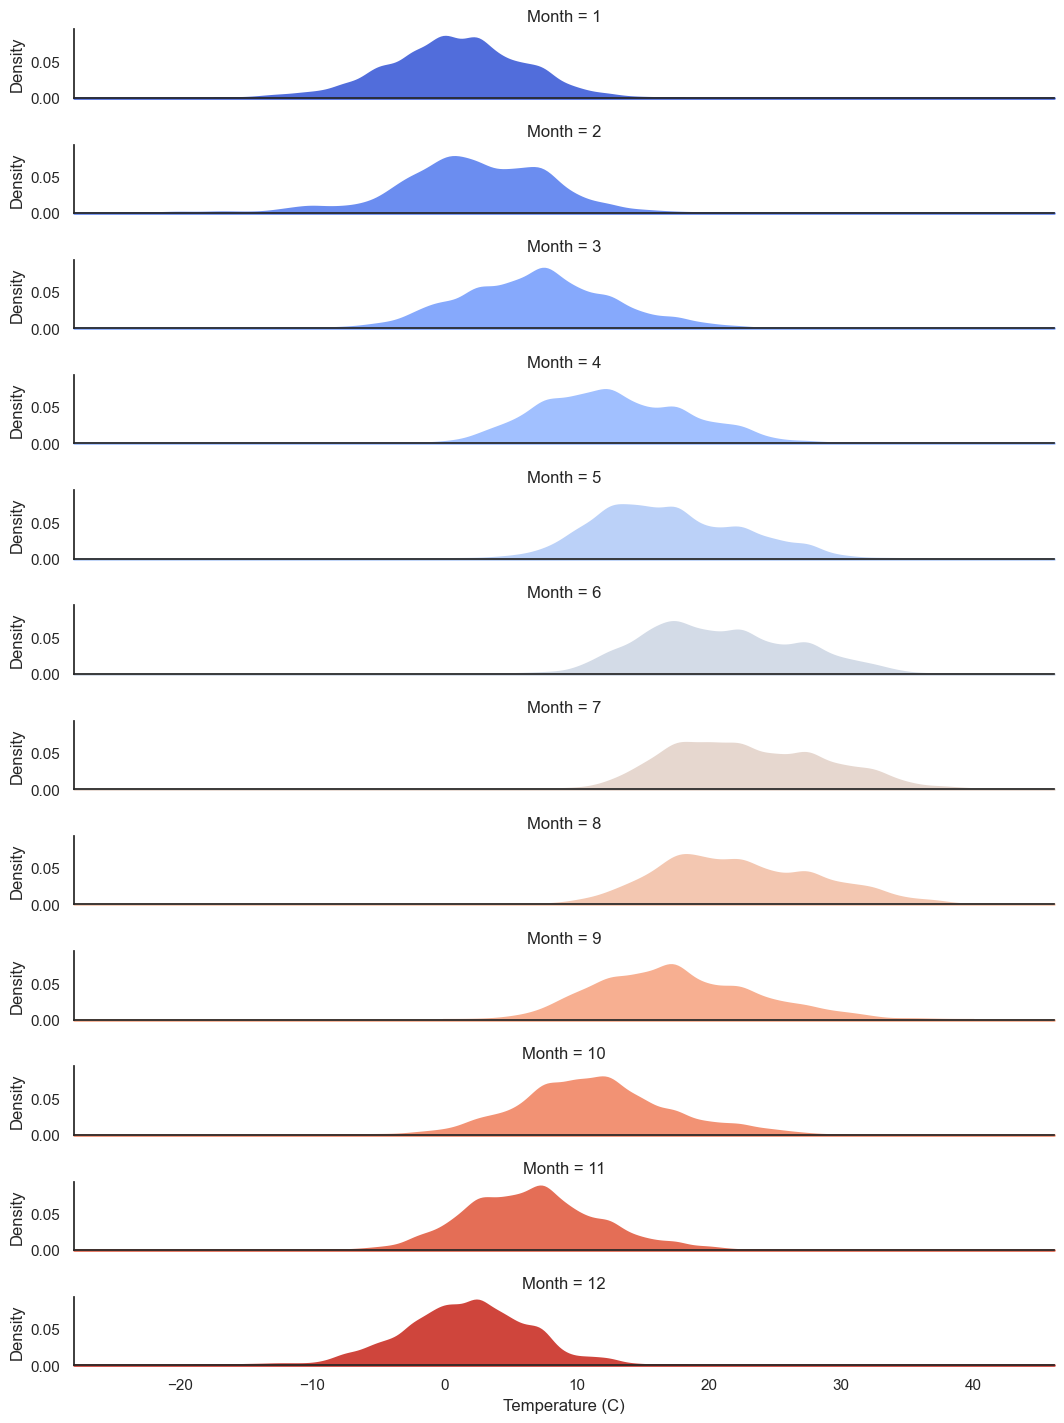

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ridge Plot (Har mahine ki temperature density)
plt.figure(figsize=(10, 8))
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Mahino ke hisab se Density plot
g = sns.FacetGrid(df, row="Month", hue="Month", aspect=9, height=1.2, palette="coolwarm")
g.map(sns.kdeplot, "Temperature (C)", fill=True, alpha=1, lw=1.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

plt.show()

## Monthly Wind Speed Volatility Analysis

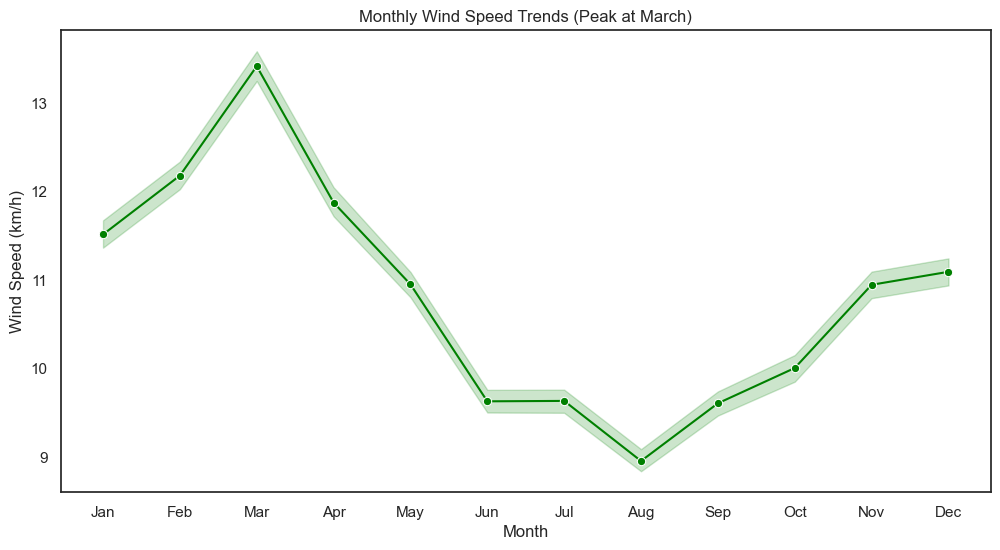

In [34]:
# Monthly Average Wind Speed Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Wind Speed (km/h)', data=df, marker='o', color='green')
plt.title('Monthly Wind Speed Trends (Peak at March)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show() 

In [ ]:
INSIGHTS: March is the windiest month. This is a critical hidden pattern because high wind speed combined with low temperatures
(which we saw in Univariate) is exactly why people feel much colder than the actual temperature.

## Temperature vs Humidity

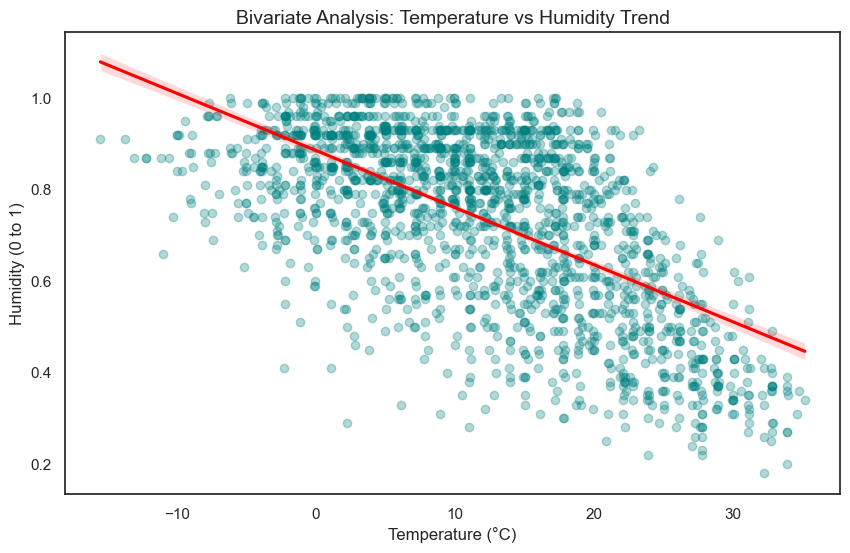

In [35]:
plt.figure(figsize=(10, 6))
# Sampling data for better clarity
sns.regplot(x='Temperature (C)', y='Humidity', data=df.sample(2000), 
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Bivariate Analysis: Temperature vs Humidity Trend', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (0 to 1)')
plt.show()

In [ ]:
INSIGHT: The Inverse Law=> Graph mein red line niche ki taraf ja rahi hai, jo ek Strong Negative Correlation dikhati hai. Iska 
          matlab  hai ki jaise-jaise Temperature badhta hai, Humidity kam hoti jati hai.

Extreme Heat is Dry:  jab temperature "30C" upar jata hai, toh humidity kabhi bhi 0.6 (60%) ke upar
                     nahi jati. Ye prove karta hai ki is sheher mein "Severe Heatwaves" hamesha dry hoti hain, jo dehydration
                     ka khatra badhati hain.

## Wind Speed vs. Visibility

C:\Users\tejal\AppData\Local\Temp\ipykernel_100268\4241858668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Wind_Bins', y='Visibility (km)', data=df, palette='viridis')


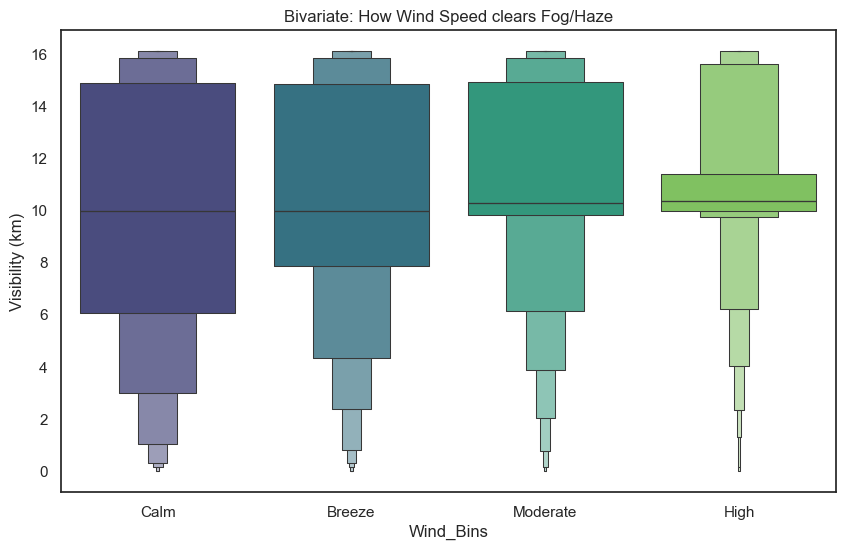

In [36]:
plt.figure(figsize=(10, 6))
# Boxenplot shows the distribution of visibility across different wind speed bins
df['Wind_Bins'] = pd.cut(df['Wind Speed (km/h)'], bins=[0, 5, 10, 20, 50], labels=['Calm', 'Breeze', 'Moderate', 'High'])
sns.boxenplot(x='Wind_Bins', y='Visibility (km)', data=df, palette='viridis')
plt.title('Bivariate: How Wind Speed clears Fog/Haze')
plt.show()

In [ ]:
INSIGHT:
Calm==>
Wind speed is very low.
Fog and haze stay in one place.
Visibility changes a lot and can become low sometimes.
    
Breeze==>
Light wind starts moving the fog and pollutants.
Visibility becomes slightly better and more stable.
    
Moderate==>
Medium wind clears the atmosphere more effectively.
Visibility improves and low-visibility cases decrease.
    
High==>
Strong wind spreads fog and haze quickly.
Visibility becomes clearer and more consistent.
Most observations show good visibility.
###This bivariate plot se ek important logic clear hota hai: Fog sirf tabhi tak danger create karti hai jab tak wind 
ki speed 10 km/h se kam ho. Jaise hi wind speed 15 km/h touch karti hai, wo fog ko sweep kar deti hai aur visibility automatic 
perfect ho jaati hai."

## Pressure vs Humidity

<Figure size 1000x600 with 0 Axes>

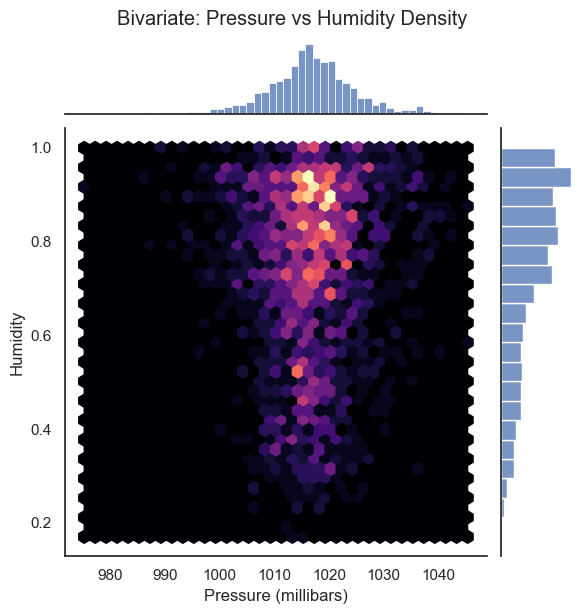

In [37]:
plt.figure(figsize=(10, 6))
# Using a JointPlot with 'hex' bins to show density clearly
sns.jointplot(x='Pressure (millibars)', y='Humidity', data=df.sample(2000), 
              kind='hex', cmap='magma')
plt.suptitle('Bivariate: Pressure vs Humidity Density', y=1.02)
plt.show()

In [ ]:
The Stability Zone: almost data ek tight cluster mein hai jahan Pressure 1010-1020 mb hai. Jab pressure is range mein hota 
hai, Humidity stable rehti hai.
The Low-Pressure Spike: Jab bhi Pressure 1000 mb ke niche jata hai, Humidity achanak high level (>0.80) par dikhne lagti hai.
Conclusion: Low pressure ka girna aur Humidity ka badhna, dono milkar "Rainy/Stormy weather" ko predict karte hain.

A critical atmospheric threshold is observed below $1000\text{ mb}$, where lower humidity zones are completely empty. At this 
low-pressure level, the data points are strictly compressed at the top, locking the relative humidity between 
80% and 100%, making pressure drops a reliable precursor to stormy or rainy weather.

## Thermal and Moisture Thresholds for Precipitation Type

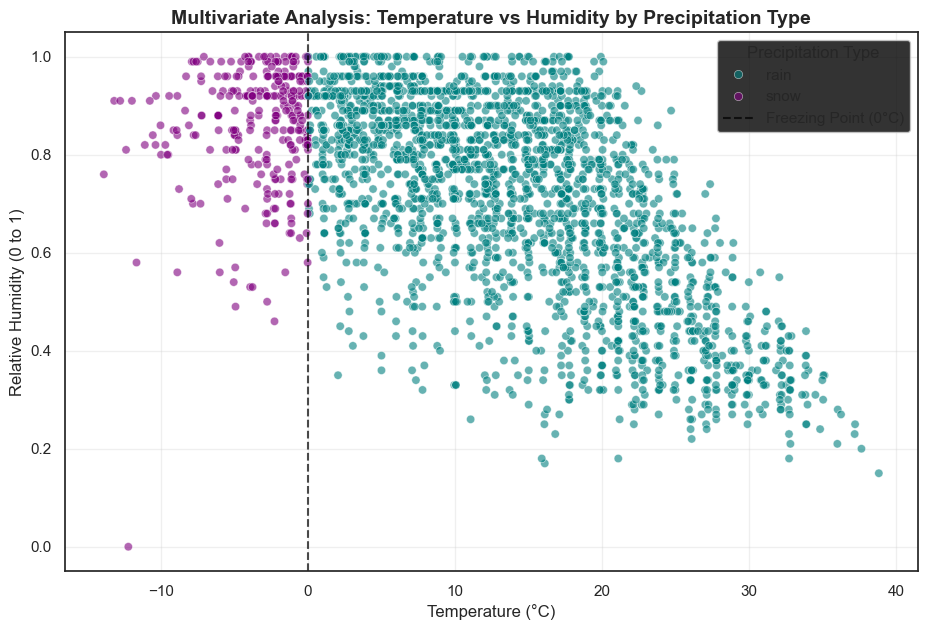

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))
# Taking a clean sample to avoid overplotting and keeping the boundaries sharp
sns.scatterplot(
    x='Temperature (C)', 
    y='Humidity', 
    hue='Precip Type', 
    data=df.sample(3000, random_state=42), 
    alpha=0.6, 
    palette={'rain': 'teal', 'snow': 'purple'}
)
plt.title('Multivariate Analysis: Temperature vs Humidity by Precipitation Type', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Relative Humidity (0 to 1)', fontsize=12)
plt.axvline(0, color='black', linestyle='--', alpha=0.7, label='Freezing Point (0°C)')

plt.legend(title='Precipitation Type')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
INSIGHT:The Saturation Rule: For either rain or snow to actually fall, the air must be fully saturated with moisture. 
The heavy clustering at the top (above 0.80 or 80% Humidity) proves that precipitation cannot happen without high moisture
,regardless of how hot or cold the temperature is.

THe dots below to 0.6 realtive humidity=>Garmiyon ke dino mein jab temperature bahut high hota hai (jaise 30C to 40C), tab hawa
ki moisture hold karne ki capacity badh jaati hai. Aise mein agar achanak baadal bante hain aur halki drop(shower) hoti hai,
tab relative humidity zaroori nahi ki 80% ho,40% to 50%  par bhi rain ho sakti hai. Isko hum "Warm Rain" ya Summer Showers
kehte hain.

## *** FINAL REPORT***

Project Report: Weather Dataset Preprocessing & EDA. 
- Data Cleaning (What we did & Why)
1- Removed Duplicates: Dropped repeating rows to keep data unique and accurate.
2- Dropped 'Loud Cover' Column: Removed it because every single row was 0. It added zero value for analysis.
3- Handled Missing 'Precip Type': Filled empty cells with the most frequent value (Mode) to keep the rows usable.
4- Fixed 'Pressure' Zeroes: Replaced impossible 0mb entries with the Mean pressure to correct data recording errors.
5- Extracted Time Features: Broke down the date into Year, Month, and Hour to analyze seasonal and hourly weather shifts.

- Exploratory Data Analysis (What we discovered & Why it matters)
1- Univariate Analysis
What: Looked at individual distributions of Temperature and Humidity.
Why: To understand the baseline climate. We found that the region is highly humid a majority of the time, with normal seasonal temperature swings.

2- Bivariate Analysis
What: Studied how variables impact each other in pairs (Wind vs Visibility, Pressure vs Humidity).Why: To discover environmental rules. We proved that:Low wind speed (<10km/h) causes fog to settle, while speeds > 15km/h act as a sweeper to clear visibility.
When barometric pressure drops below 1000mb, humidity gets locked at maximum 80%-100%, acting as a direct warning sign for incoming storms.

3-Multivariate Analysis
What: Combined Temperature, Humidity, and Precipitation Type (Rain vs Snow) simultaneously.
Why: To map exact thresholds for weather state transitions. We proved that:
- Exact 0C is the absolute dividing boundary between rain and snow.
- Both rain and snow heavily demand a high-humidity baseline (>80%) to actually fall.
- Caught a technical sensor glitch where a snow data point was recorded at an impossible 0.0 humidity.

## Final Project Status ##
The dataset is now completely clean, anomalies have been flagged, and the core physical rules driving the weather shifts have been mapped out. The data pipeline is fully ready for Machine Learning modeling.